# M4: Graph Assignment

**Instructions:**

Create the appropriate graphic for each scenario. Please use a different Jupyter cell for each one. You will be given a prompt and a source file.

**Completed By:** Danni Martin, September 22, 2024.

In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

## Health Opportunity Index

Using the file Health_Opportunity_Index, create a graph to visualize the relationship that exists between the “Affordability” metric and the “Health Opportunity Index” in the state of Virginia. Explicitly justify your choice of the type of graph and interpret your result in a single paragraph, using markdown-text.

In [6]:
# Load Health_Opportunity_Index.csv into dataframe.
health = pd.read_csv('Health_Opportunity_Index.csv')

# Review new dataframe.
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1875 entries, 0 to 1874
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Census Tract              1875 non-null   int64  
 1   Rural~Urban               1875 non-null   object 
 2   Access to Care            1875 non-null   float64
 3   Employment Accessibility  1875 non-null   float64
 4   Affordability             1875 non-null   float64
 5   Health Opportunity Index  1875 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 88.0+ KB


In [7]:
# Rename columns.
health.columns = [col.lower().replace(" ", "_") for col in health.columns]

In [8]:
# Review df.
health.head()

,census_tract,rural~urban,access_to_care,employment_accessibility,affordability,health_opportunity_index
0,51650011400,Urban,0.486042,0.015251,0.043043,0.000000
1,51760040300,Urban,0.502987,0.042804,0.641642,0.015558
2,51013101701,Urban,0.432198,0.131224,0.627628,0.032861
3,51710002500,Urban,0.465814,0.041683,0.021021,0.077873
4,51760040400,Urban,0.502987,0.084305,0.662663,0.085121


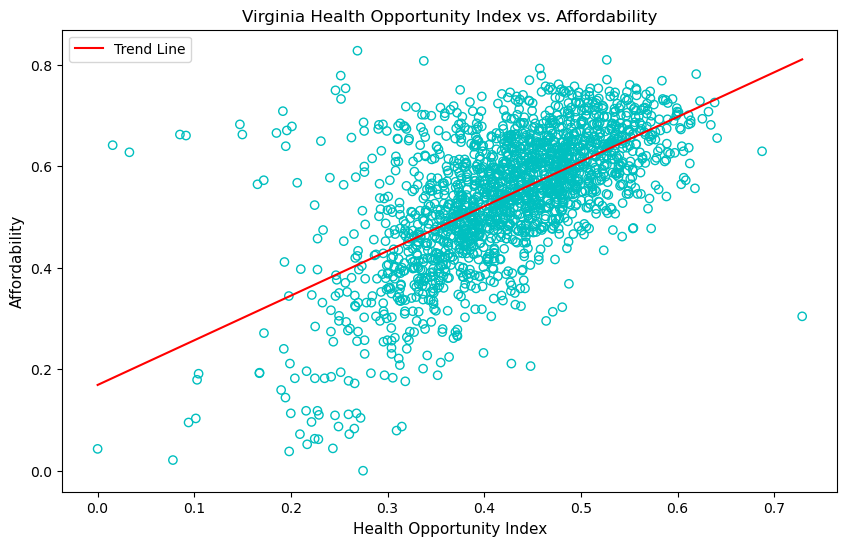

In [9]:
# Plot "Health Opportunity Index" versus "Affordability" and set labels.
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(health.health_opportunity_index, health.affordability, facecolors='none', edgecolors='c')
ax.set_title('Virginia Health Opportunity Index vs. Affordability')
ax.set_xlabel('Health Opportunity Index', fontsize=11)
ax.set_ylabel('Affordability', fontsize=11)

# Fit the trend line.
z = np.polyfit(health.health_opportunity_index, health.affordability, 1)
p = np.poly1d(z)
plt.plot(health.health_opportunity_index,p(health.health_opportunity_index), label='Trend Line', color='red')

# Show legend.
plt.legend()

# Show plot.
plt.show()

### Analysis

To visualize the relationship between Health Opportunity Index (HOI) and Affordability in the state of Virginia, a scatterplot was chosen due to its usefulness for identifying patterns and potential outliers. Empty circles were used for points to enhance visualization of varying density. Axes were labeled accordingly and an appropriate figure title was included. A positive relationship between HOI and Affordability is observed. This relationship is further emphasized by the inclusion of a trend line.

## Dropout Rates

In [12]:
# Load DropoutRates.csv into dataframe
dropout = pd.read_csv('DropoutRates.csv')

# Review new dataframe
dropout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Race/ethnicity  6 non-null      object 
 1   Male            6 non-null      float64
 2   Female          6 non-null      float64
dtypes: float64(2), object(1)
memory usage: 276.0+ bytes


In [13]:
# New df for graph - remove total from dataset and calculate average rate per group for sorting.
# Remove totals from df.
do = dropout.loc[1:]

# New column for Average Dropout rate per ethnicity.
do['Average Dropout Rate'] = do.loc[:, ('Male', 'Female')].mean(axis=1)

# Sort values by new column.
do = do.sort_values(by='Average Dropout Rate')

C:\Users\danie\AppData\Local\Temp\ipykernel_31344\2903578587.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  do['Average Dropout Rate'] = do.loc[:, ('Male', 'Female')].mean(axis=1)


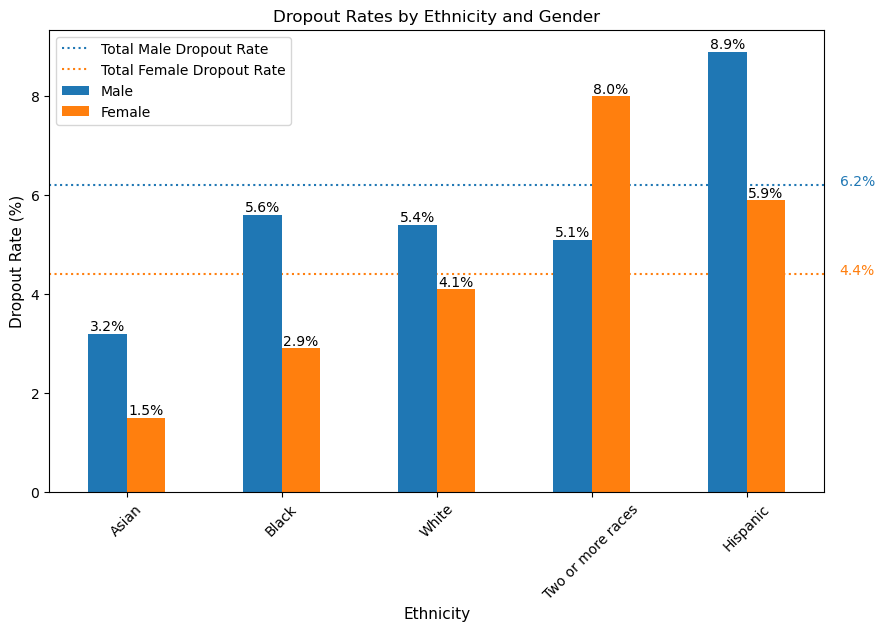

In [14]:
# Create a grouped bar chart.
ax = do.plot(x='Race/ethnicity', y=['Male', 'Female'], kind='bar', figsize=(10, 6))

# Set the title and labels.
plt.title('Dropout Rates by Ethnicity and Gender')
plt.xlabel('Ethnicity', fontsize=11)
plt.ylabel('Dropout Rate (%)', fontsize=11)
plt.bar_label(ax.containers[0], fmt= '%.1f%%')
plt.bar_label(ax.containers[1], fmt= '%.1f%%')

# Add total lines.
plt.axhline(y = 6.2, color = 'tab:blue', linestyle = ':', label = 'Total Male Dropout Rate', zorder=0)
plt.axhline(y = 4.4, color = 'tab:orange', linestyle = ':', label = 'Total Female Dropout Rate', zorder=0)
plt.text(x= 4.6, y=6.2, s='6.2%', color='tab:blue', zorder=0)
plt.text(x= 4.6, y=4.4, s='4.4%', color='tab:orange', zorder=0)

# Rotate x tick labels.
plt.xticks(rotation=45)

# Show legend.
plt.legend()

# Show the plot.
plt.show()

### Analysis

To visualize how dropout rates vary by gender and ethnicity, a grouped bar chart was chosen due to its usefulness for depicting multiple categories. Colors were used to differentiate between men and women.
Axes and bars were labeled accordingly and an appropriate figure title was included.

 Horizontal lines were used to annotate total dropout rates for men and women, regardless of ethnicity. Horizontal lines were chosen as this allows for quick analysis of how each group compares to the average.

 Given the data provided, Asians had the lowest dropout rate and Hispanics had the highest. Two or more races is the only category where women had a higher dropout rate than men. Dropout rates seem to vary depending on ethnicity and gender; however, additional analysis would be needed to determine significance.

## US Food Imports

Using the file US Food Imports.csv, build a graph that shows how the US food imports have changed over time, from 2010 to 2021. Show a comparison of the total imports, animal imports, plant imports, and beverage imports. Explicitly justify your choice of the type of graph and interpret your result in a single paragraph, using markdown-text.

In [18]:
# Load 'US Food Imports.csv' into dataframe
food = pd.read_csv('US Food Imports.csv')

# Review dataframe.
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            12 non-null     int64  
 1   TotalUSImports  12 non-null     float64
 2   Animals         12 non-null     float64
 3   Plants          12 non-null     float64
 4   Beverages       12 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 612.0 bytes


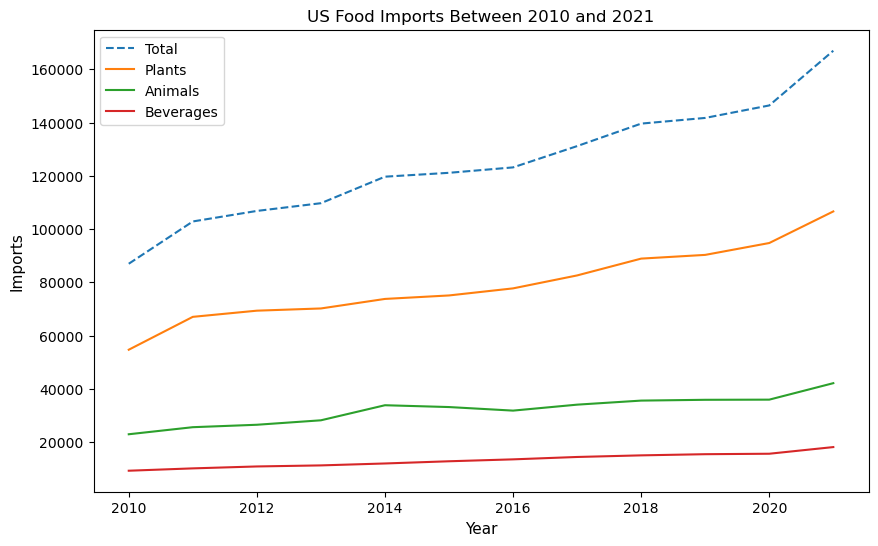

In [19]:
# Create x axis variable.
x = food['Year']

# Plot data.
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, food.TotalUSImports, label = 'Total', linestyle='--')
ax.plot(x, food.Plants, label = 'Plants')
ax.plot(x, food.Animals, label = 'Animals')
ax.plot(x, food.Beverages, label = 'Beverages')

# Set labels.
ax.set_title('US Food Imports Between 2010 and 2021')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Imports', fontsize=11)

# Show legend.
plt.legend()

# Show plot.
plt.show()

### Analysis

To visualize how US food imports have changed between 2010 and 2021, a line chart was chosen due to its usefulness for depicting continuous variables.
The linestyle was modified for 'Total' to further differentiate it from the other categories. Each category was differentiated using colors. Total imports have increased between 2010 and 2021; however, the units are unclear given the information provided. Plant imports are consistenly higher, followed by Animals, and lastly Beverages.

## Oil Barrel Price Variation

Using the file Oil Barrel Price Variation.csv, create a graph where you can visualize the variation of the price of crude oil per barrel over time. Decompose the time series if you are using one. Can you describe a trend? Does it have seasonal variation? Highlight any particular points or events in the graph that you believe require attention and exploring further to find their potential causes. If so, provide some possible explanations. Explicitly justify your choice of the type of graph and interpret your result in a single paragraph, using markdown-text.

In [23]:
# Load 'US Food Imports.csv' into dataframe.
oil = pd.read_csv('Oil Barrel Price Variation.csv')

# Review df.
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 2 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Month                                                     396 non-null    object 
 1   Brent crude oil spot price, Monthly (dollars per barrel)  396 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


In [24]:
# Set index.
oil.set_index('Month',inplace=True)

# Convert index to datetime.
oil.index=pd.to_datetime(oil.index, format='%Y %m')

# Review df.
oil.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 396 entries, 1990-01-01 to 2022-12-01
Data columns (total 1 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Brent crude oil spot price, Monthly (dollars per barrel)  396 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB


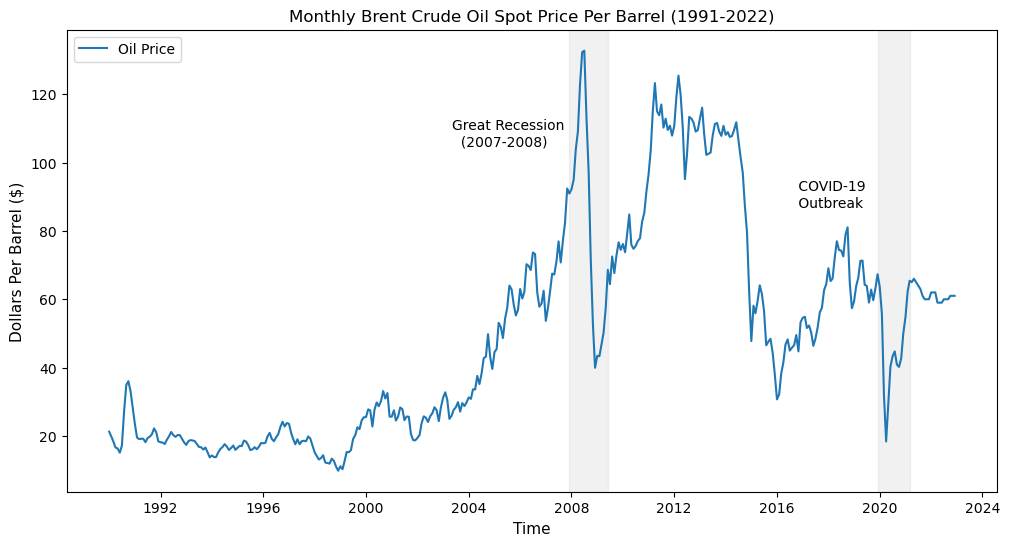

In [25]:
# Plot timeseries
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(oil, label='Oil Price')

# Set title and labels.
ax.set_title('Monthly Brent Crude Oil Spot Price Per Barrel (1991-2022)')
ax.set_xlabel('Time', fontsize=11)
ax.set_ylabel('Dollars Per Barrel ($)', fontsize=11)

# Annotate areas of interest.
# Great Recession
ax.axvspan(oil.index[215], oil.index[233], color='tab:gray', alpha=0.1)
plt.text(x = mdates.date2num(oil.index[160]), y = 105, s = 'Great Recession \n  (2007-2008)', fontsize=10)
# COVID-19
ax.axvspan(oil.index[359], oil.index[374], color='tab:gray', alpha=0.1)
plt.text(x = mdates.date2num(oil.index[320]), y = 87, s = ' COVID-19\n Outbreak', fontsize=10)

# Show legend.
plt.legend()

# Show plot.
plt.show()

In [26]:
# Time series decompostion.
result = seasonal_decompose(oil['Brent crude oil spot price, Monthly (dollars per barrel)'], model='multiplicative', period=12)

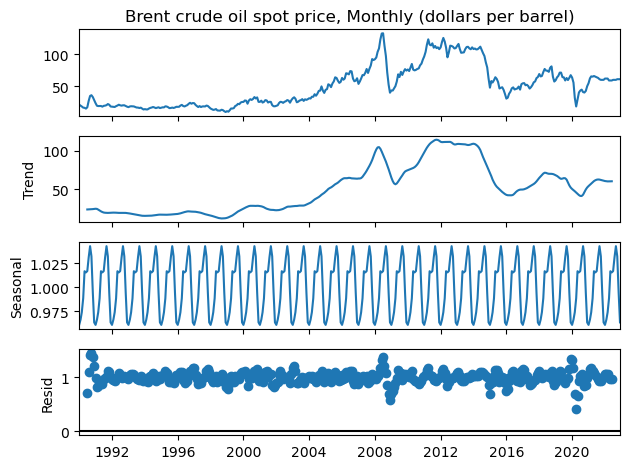

In [27]:
# Plot time series decomposition.
result.plot()
plt.show()

### Analysis

To visualize the variation of crude oil prices, a time series graph was created; in addition to, a supplemental time decomposition plot.

For the time series, two key events, the 2008 Financial Crisis and 2020 COVID-19 outbreak, are annotated. Sharp dips are observed for both of these events. The 2008 recession led to a general drop in asset prices globally as credit contracted and earnings projections fell. The 2008 Financial Crisis also led to increased unemployment and reduced spending; consequently, lowering the demand for oil by consumers and businesses. In 2020, oil prices plunged again due to the COVID-19 pandemic. In response to the outbreak, governments worldwide enforced lockdowns and travel restrictions to curb the virus' spread; therefore, demand for oil dropped in tandem. Axes and events were labeled accordingly and an appropriate figure title was included.

When decomposing the time series, we observe a non-linear trend and seasonality. Crude oil prices rise during the summer months and decline in the winter months.